Пока наши векторы - это просто красивые числа. Слово «он» в предложении «Кот любил сметану, он был счастлив» не знает, что оно относится к слову «Кот». Слово «сметану» не понимает, что его кто-то любит. Каждый вектор существует сам по себе, изолированно.

В этой главе мы добавим нейросети способность понимать контекст. Мы реализуем механизм, который позволит каждому слову «заглянуть» в другие слова предложения и понять связи между ними. Это и есть Механизм Внимания (Attention Mechanism) - сердце современного ИИ.

## Эпоха до Внимания: RNN и LSTM

В начале 2010-х годов доминировали рекуррентные нейронные сети (RNN) и их улучшенные версии - LSTM (Long Short-Term Memory). **Эти модели обрабатывали текст последовательно, слово за словом**:

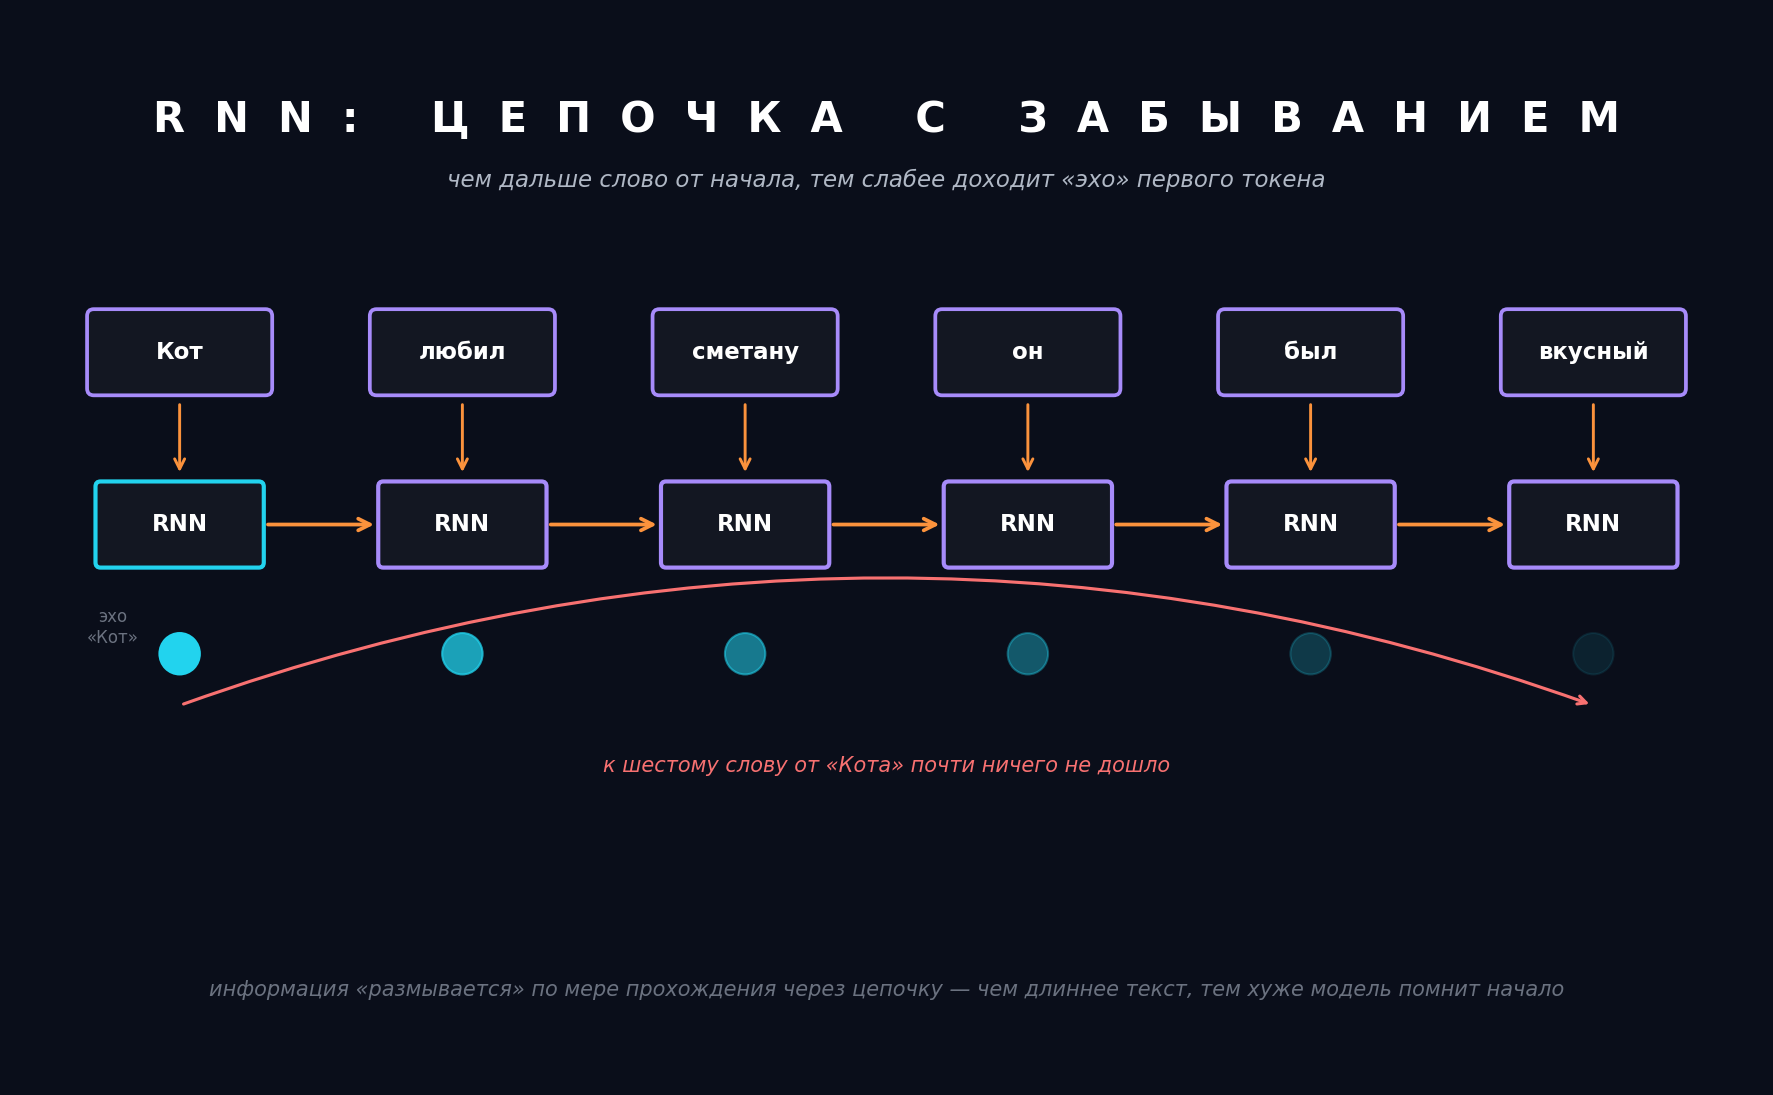

**Проблема 1: Последовательная обработка:**

Невозможно распараллелить вычисления. Чтобы обработать слово №100, нужно сначала обработать слова №1-99. Это медленно, особенно на длинных текстах.

**Проблема 2: Потеря контекста:**

Представьте, что вы читаете книгу, и вам нужно запомнить имя персонажа, упомянутого 50 страниц назад. RNN работали похоже: информация «размывалась» по мере прохождения через цепочку. Чем дальше слова друг от друга, тем слабее связь между ними.

**Проблема 3: «Бутылочное горлышко»:**

В архитектурах Encoder-Decoder всё предложение сжималось в один фиксированный вектор. Представьте, что вы пытаетесь пересказать «Войну и Мир» в одном предложении. Много информации терялось.

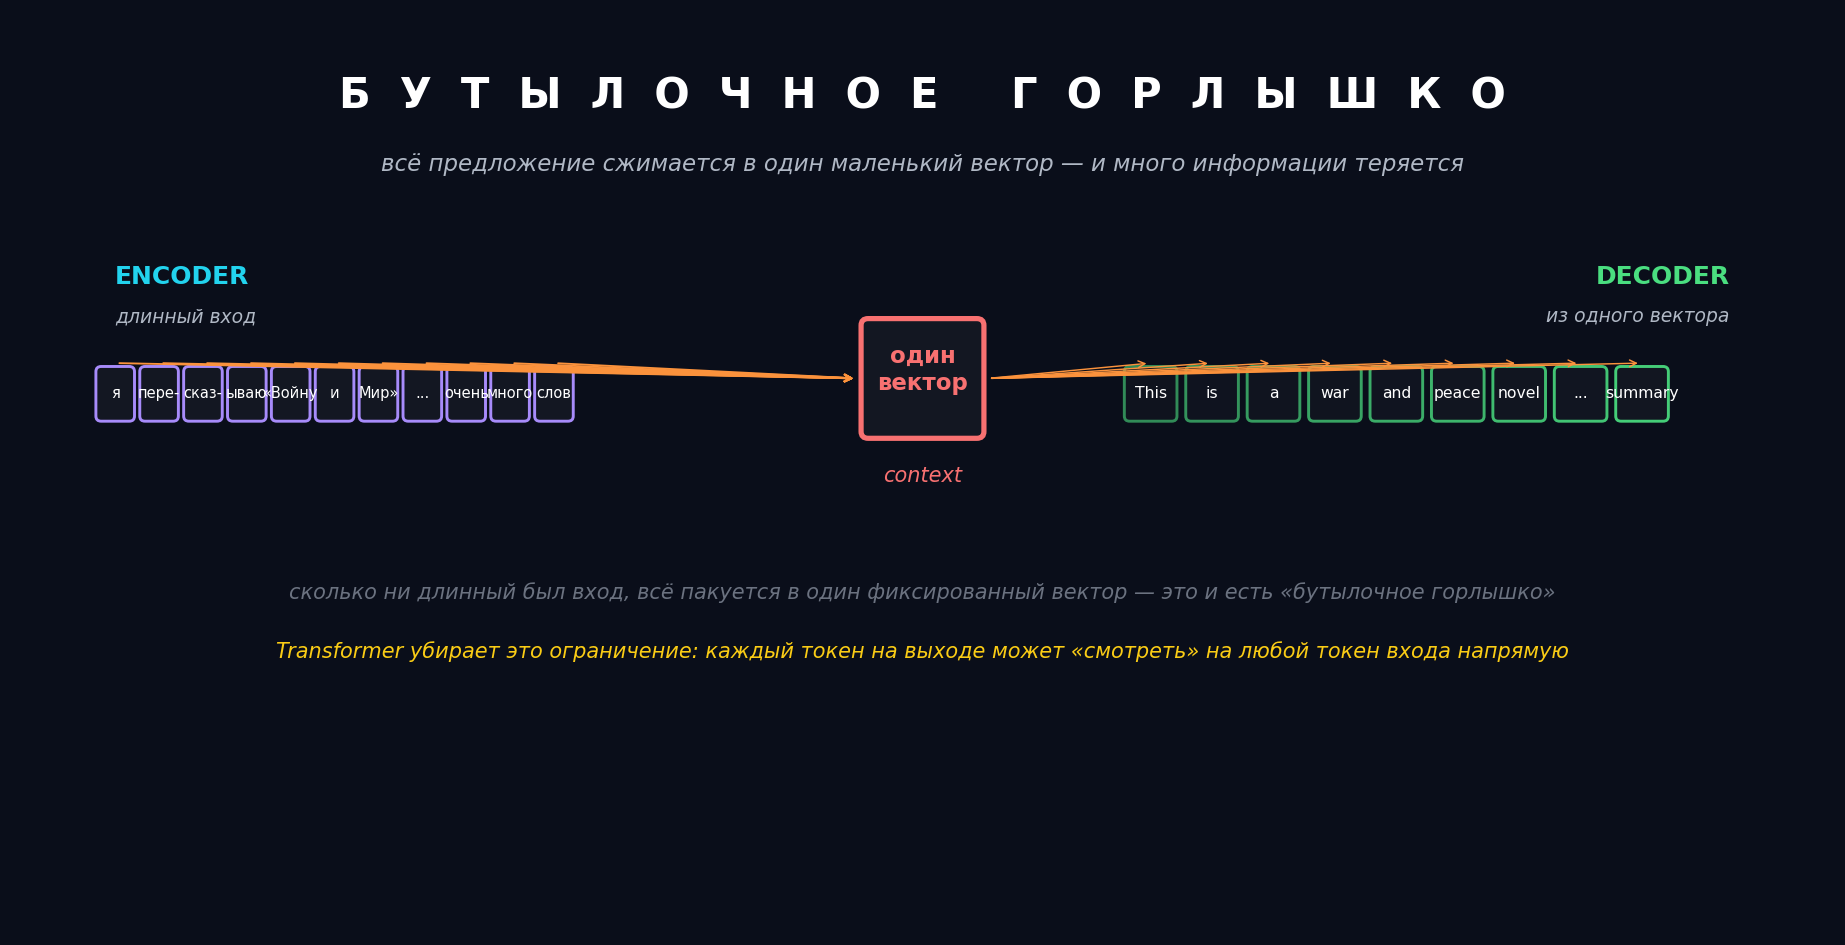

## 2017 год: «Attention Is All You Need»

Команда Google опубликовала статью, которая перевернула всё. Они предложили архитектуру Transformer, которая полностью отказалась от рекуррентности. Вместо последовательной обработки - только механизм внимания.

**Результат:**

* Обучение распараллеливается (все слова обрабатываются одновременно)
* Контекст сохраняется на любых расстояниях (прямая связь между любыми токенами)
* Качество выросло значительно

Сегодня GPT, BERT, Llama - все основаны на этой идее.

**Механизм Внимания позволяет каждому токену в последовательности взаимодействовать с каждым другим токеном, вычисляя степень их взаимосвязи.**

**Пример: Разрешение местоимений**

Возьмём предложение:

«**Кот** любил сметану, потому что **он** был вкусный»

Вопрос: к кому относится местоимение «он»?

**Вариант А:** К коту (кот был вкусный? Странно...)

**Вариант Б:** К сметане (сметана была вкусная? Логично!)


Человек понимает это мгновенно, анализируя контекст. Механизм Внимания делает то же самое:

Токен «он» спрашивает:
→ «Кот» - насколько ты связан со мной? (Ответ: 0.3)

→ «любил» - насколько ты связан со мной? (Ответ: 0.1)

→ «сметану» - насколько ты связан со мной? (Ответ: 0.6)

→ «потому» - насколько ты связан со мной? (Ответ: 0.0)

...

Вывод: «он» больше всего внимания уделяет «сметану»

**Пример: Улавливание грамматических связей**

«**Кошки**, которые **жили** в **доме**, ловили **мышей**»

Механизм Внимания помогает модели понять:

«Кошки» ↔ «ловили» (кто выполнял действие)

«ловили» ↔ «мышей» (над кем выполнялось действие)

«доме» ↔ «жили» (где происходило действие)

Эти связи называются **зависимостями**. В лингвистике их изучают десятилетиями. Transformer выучивает их автоматически в процессе обучения.

## Как работает Самовнимание (Self-Attention)

Теперь перейдём к самому механизму. Мы начнём с упрощённой версии **без обучаемых весов**, чтобы понять суть. Позже мы добавим веса и сделаем механизм полноценным.

Каждый токен в предложении создаёт запрос (**Query**): «Какие другие токены мне важны?»

Каждый токен также предоставляет ключ (**Key**): «Вот информация обо мне, обращайся если нужно»

И каждый токен имеет значение (**Value**): «Вот моё фактическое содержание»



$$(Q, K, V)$$

**Важно:** в этой упрощённой версии **Q = K = V = X** (то есть Query, Key и Value - это просто наш входной вектор, без всяких преобразований). Полноценное разделение на три разных представления появится в следующей главе, когда мы добавим обучаемые матрицы. Сейчас же три буквы - это «три роли», которые играет один и тот же вектор.

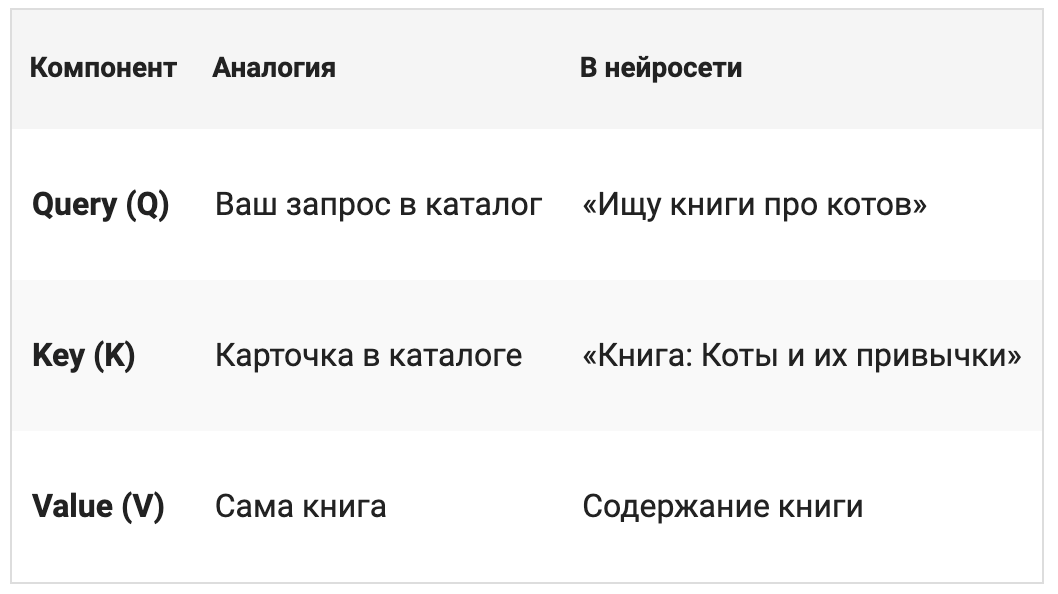

**Процесс:**

1. Вы приходите с **Query** (запросом)
2. Сравниваете его со всеми **Key** (карточками каталога)
3. Находите совпадения - получаете **Attention Scores** (оценки релевантности)
4. Забираете **Value** (книги) пропорционально оценкам

**В нейросети каждый токен одновременно и читатель, и книга!**

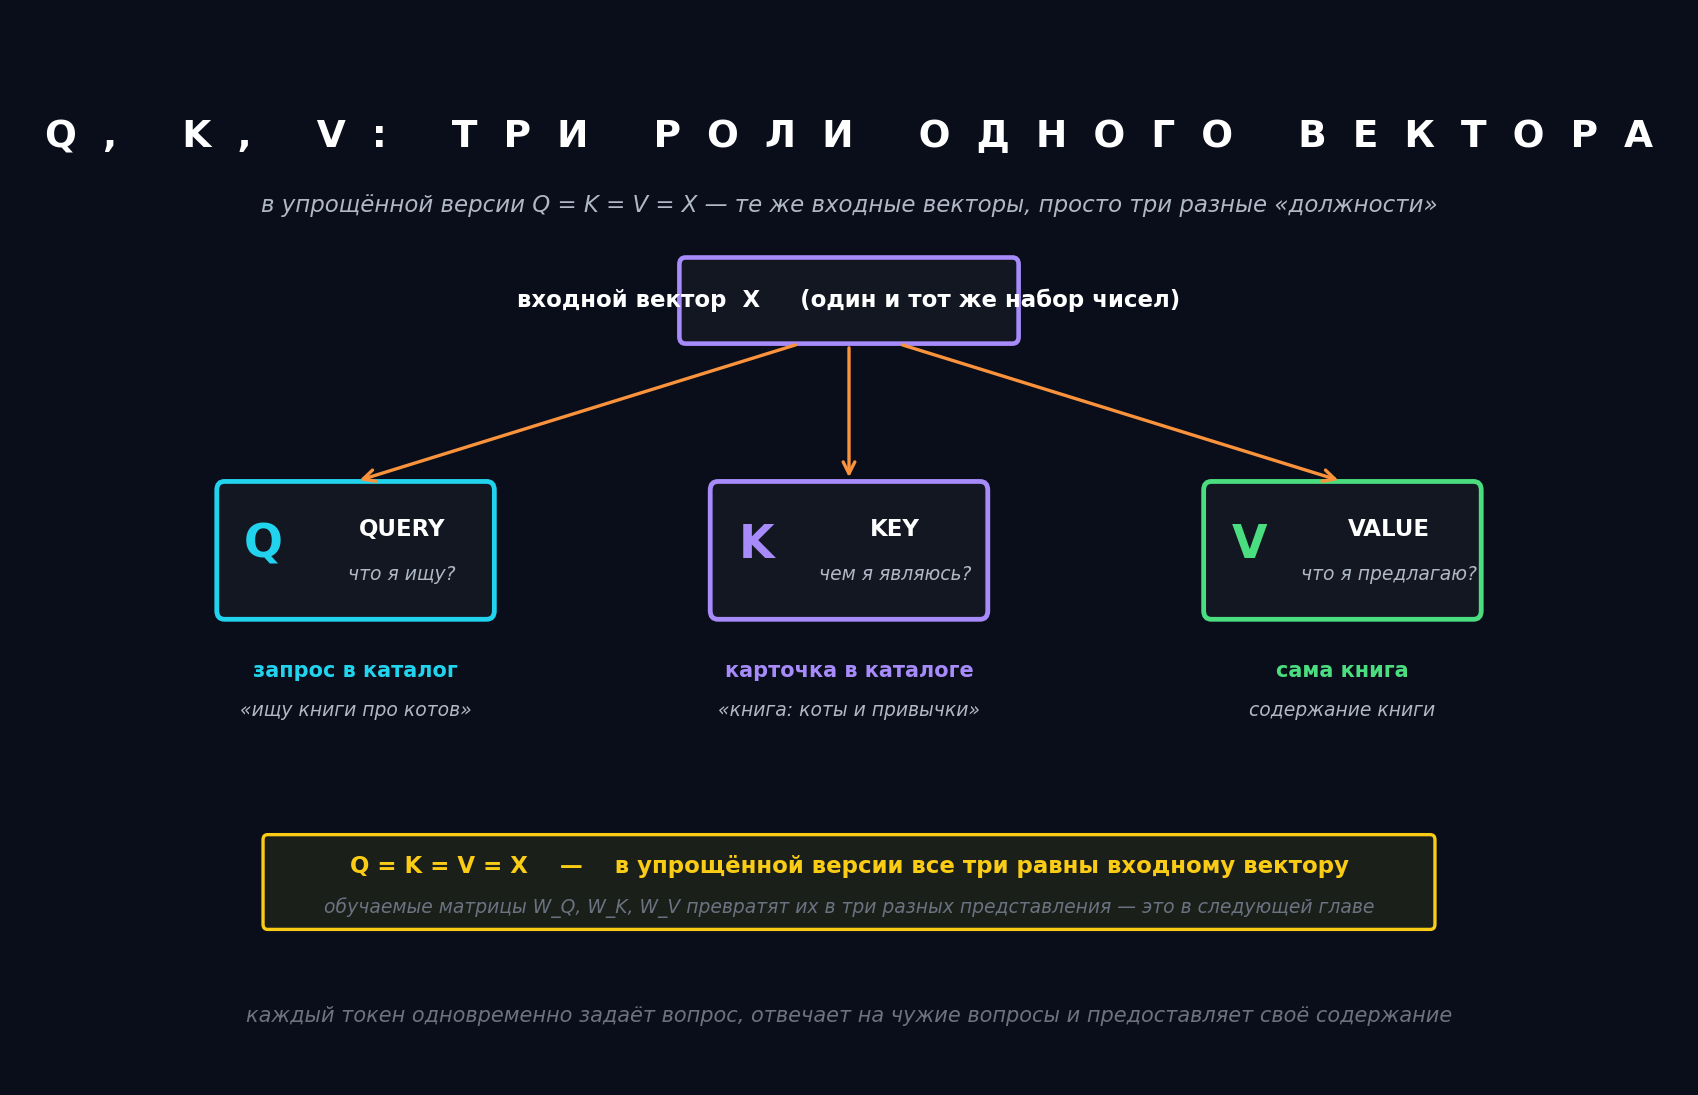

## Исходные данные: Наши векторы

Представим, что у нас уже есть токенизированный текст. Мы прошли все предыдущие модули: текст превращён в токены, токены превращены в векторы.

У нас есть 3 токена, и каждый представлен вектором из 3 чисел (для простоты мы уменьшили размерность с 16 до 3, чтобы вычисления поместились на странице).

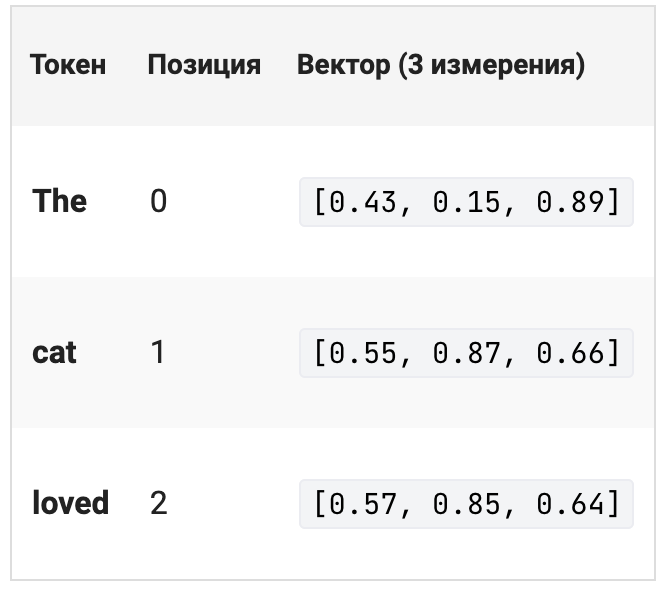

Запишем это как матрицу **X** (наши входные данные):

$$
X =
\begin{bmatrix}
0.43 & 0.15 & 0.89 \\
0.55 & 0.87 & 0.66 \\
0.57 & 0.85 & 0.64
\end{bmatrix}
$$

- 3 строки - это 3 токена
- 3 столбца - это 3 измерения вектора (embed_dim = 3)

Теперь наша задача - для каждого токена вычислить контекстный вектор, который содержит информацию о всех остальных токенах, взвешенную по важности.

**Вычисляем показатели внимания (Attention Scores)**

**Вопрос:** Насколько каждый токен «похож» на каждый другой токен?

**Инструмент:** Скалярное произведение векторов (dot product). Помните, мы это изучали в мини-курсе по математике.

Результат:

- **Большое положительное число** → векторы направлены в одну сторону (похожи)
- **Отрицательное число** → векторы направлены в противоположные стороны (разные)
- **Около нуля** → векторы перпендикулярны (не связаны)

Нам нужно вычислить скалярное произведение **для каждой пары токенов**. У нас 3 токена, значит будет 3×3 = 9 вычислений.

Запишем в матрицу:

$$
\mathrm{Scores} =
\begin{bmatrix}
0.9995 & 0.9544 & 0.9422 \\
0.9544 & 1.4950 & 1.4754 \\
0.9422 & 1.4754 & 1.4570
\end{bmatrix}
$$

- Строка 0 - насколько «The» похож на каждый токен
- Строка 1 - насколько «cat» похож на каждый токен
- Строка 2 - насколько «loved» похож на каждый токен

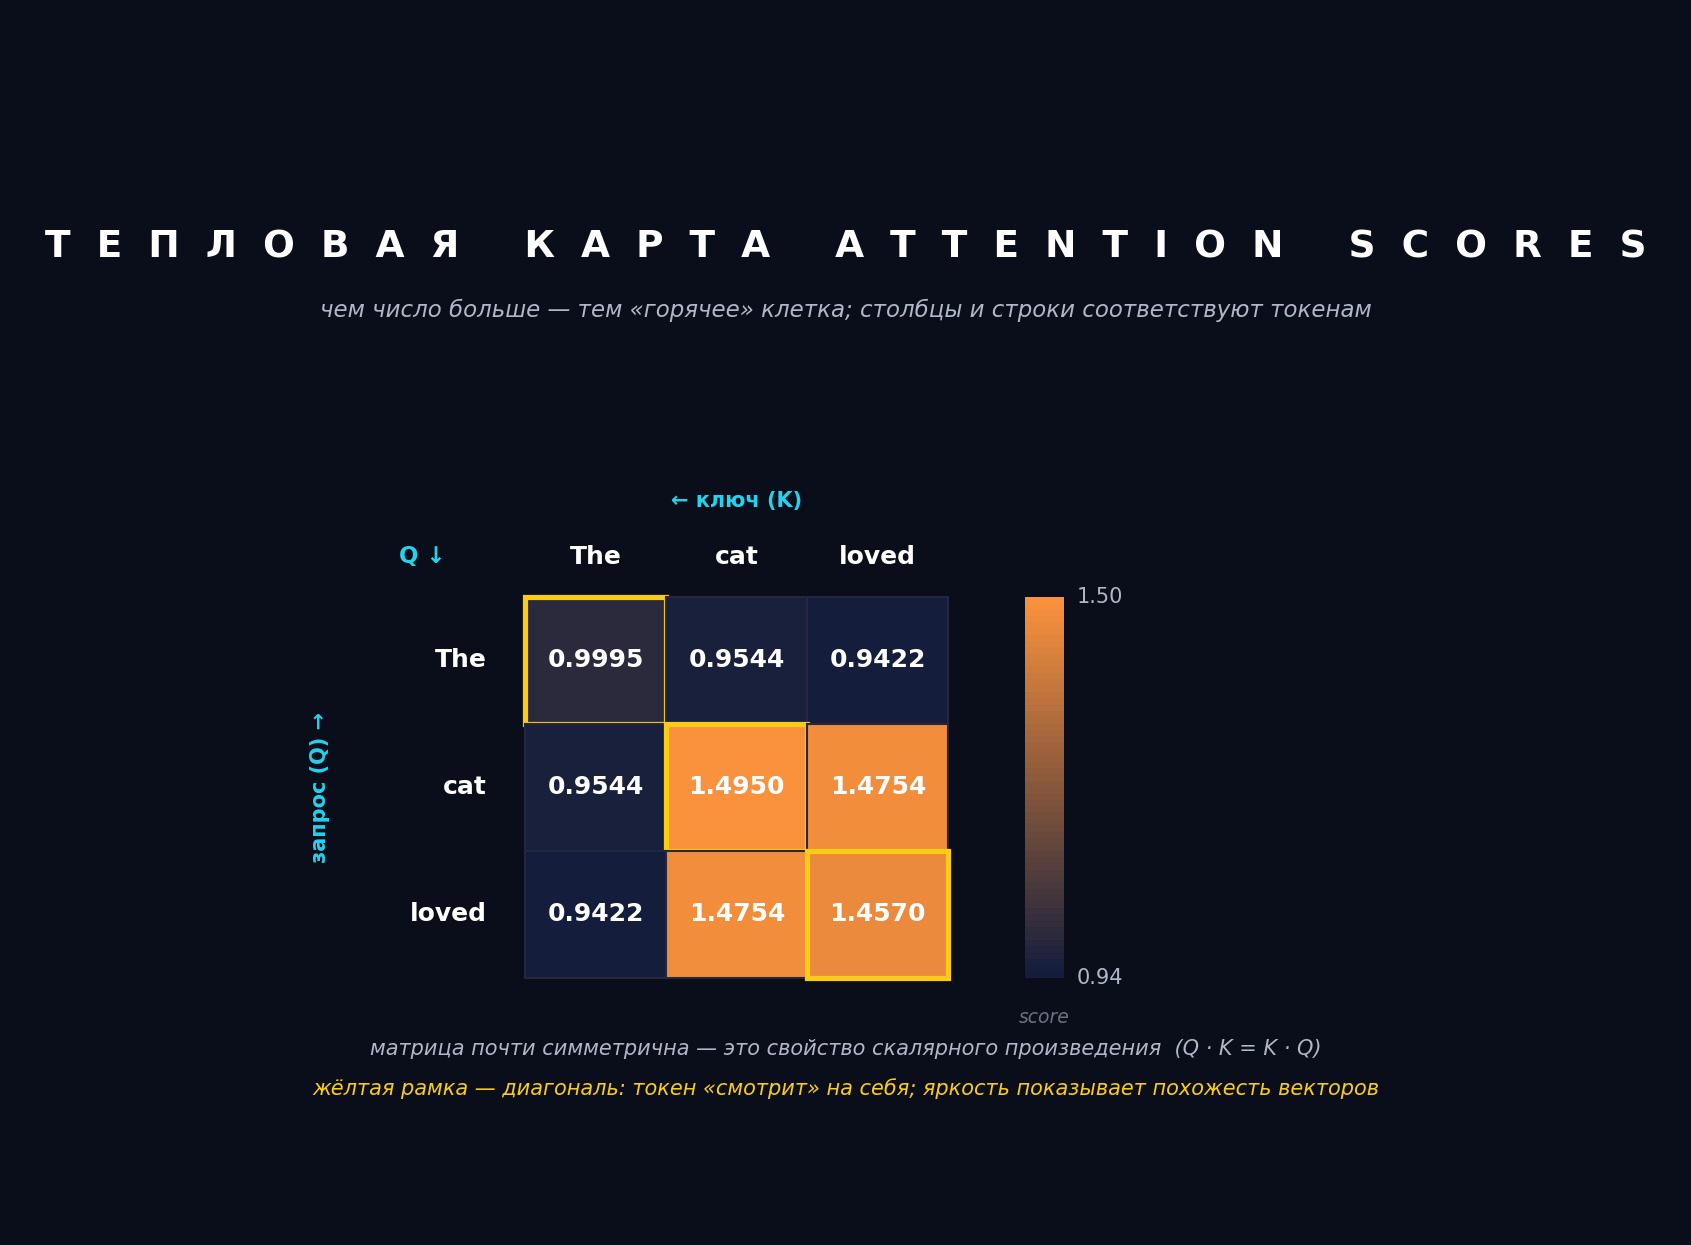

**Важно:**

- Диагональ обычно (но не всегда) максимальна - в большинстве случаев токен сильнее всего «похож» на самого себя. Но обратите внимание на строку loved: значение loved·cat = 1.4754 больше, чем loved·loved = 1.4570. Так получилось потому, что вектор cat имеет немного большую длину, чем loved, а скалярное произведение зависит и от направления, и от величины векторов
- Матрица симметрична - The·cat = cat·The (это свойство скалярного произведения).
- cat и loved очень похожи (1.4754) - оба вектора имеют большие значения во 2-м и 3-м измерениях.
- The менее похож на остальные - его вектор отличается (большое значение в 3-м измерении, но маленькое во 2-м).

Но есть проблема: эти числа (scores) нельзя использовать напрямую. Так как они:

- Не суммируются в 1
- Могут быть больше 1
- Не интерпретируются как «доля внимания»

Вот тут нам нужна функция **softmax**!

Что это нам даёт:

- Все значения становятся положительными (экспонента всегда положительна)
- Все значения в сумме дают 1 (нормализация)
- Можно интерпретировать как вероятности или доли

**Последовательно вычисляем softmax для каждой строки. И сводим в одну матрицу весов.**

$$
\mathrm{Weights} =
\begin{bmatrix}
0.3448 & 0.3296 & 0.3256 \\
0.2272 & 0.3902 & 0.3826 \\
0.2284 & 0.3893 & 0.3823
\end{bmatrix}
$$

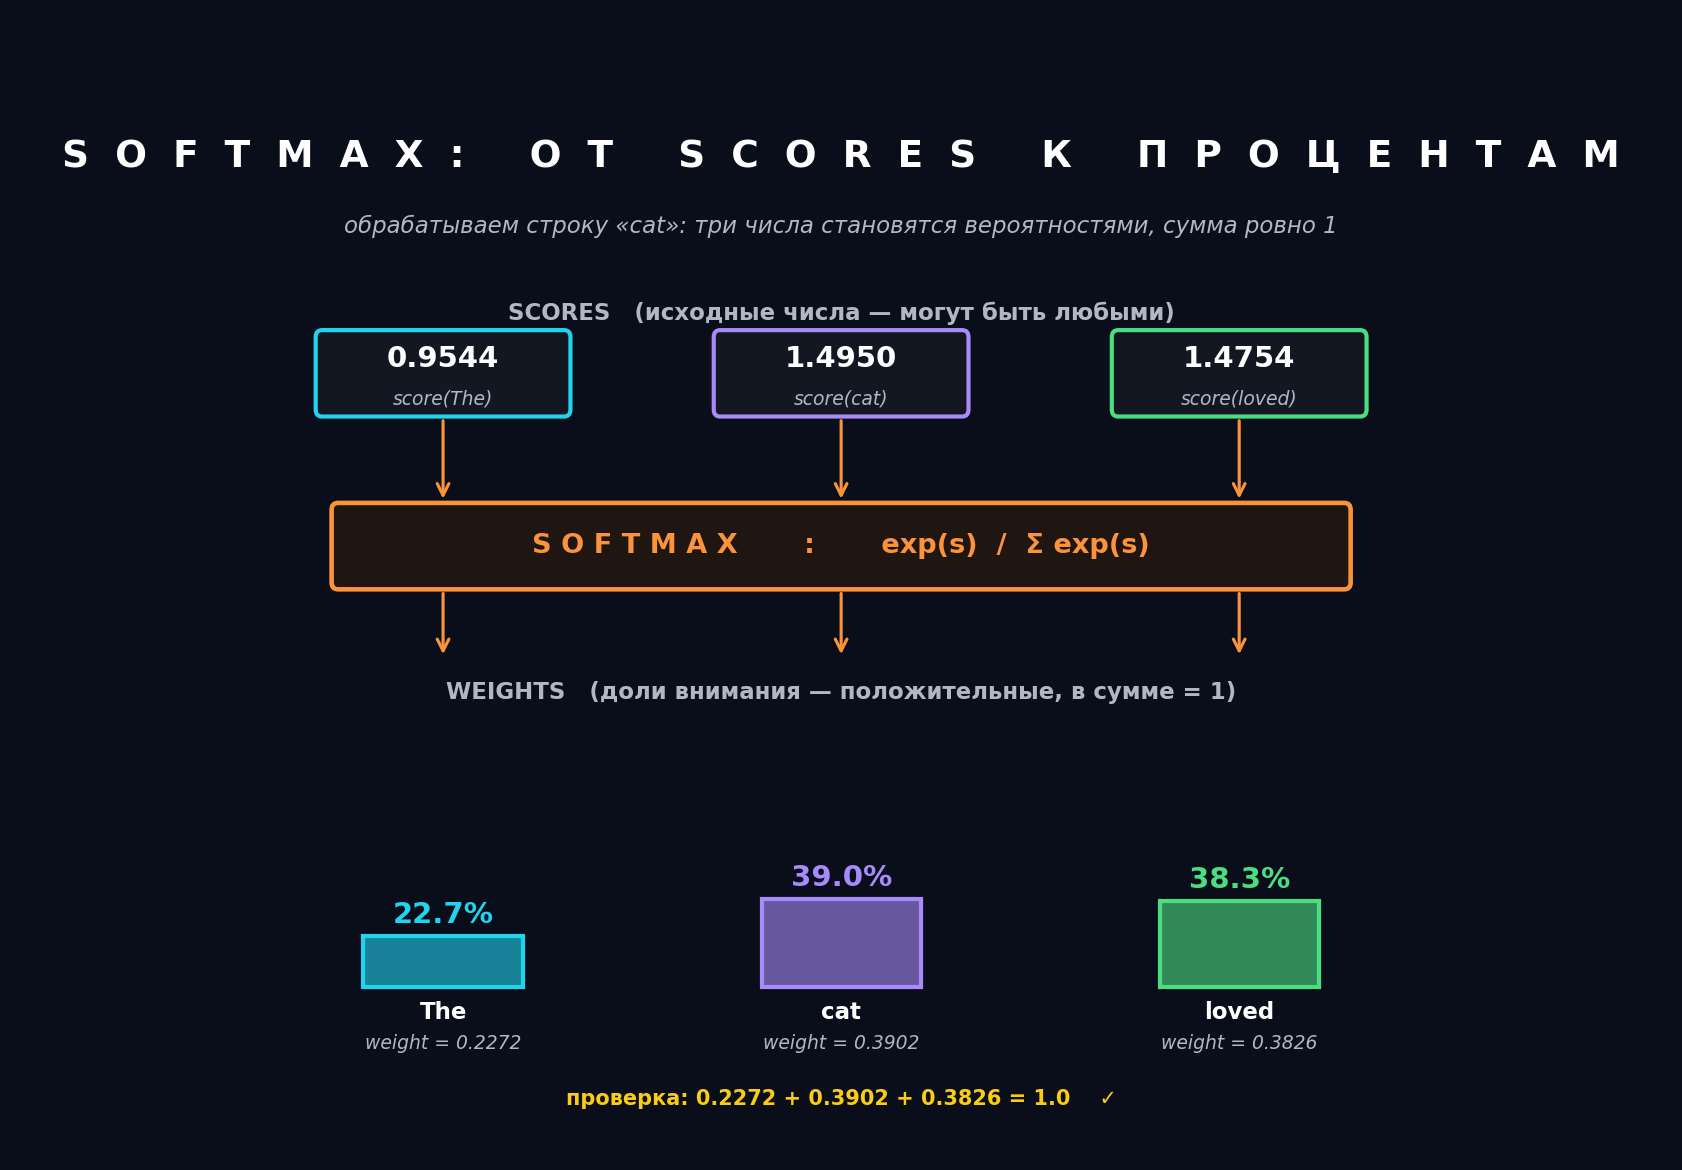

И вот мы подходим к получению контекстных векторов. Имея веса и исходные векторы, мы выполним это очень просто.

Необходимо сделать новый вектор для каждого токена, который содержит информацию от всех токенов, взвешенную по важности.

Формула следующая:

$$z_i = weight_{i1}\cdot x_1 + weight_{i2}\cdot x_2 + weight_{i3}\cdot x_3$$

**Это взвешенная сумма всех входных векторов.**

**Итоговая матрица контекстных векторов:**

$$
Z =
\begin{bmatrix}
0.5152 & 0.6153 & 0.7328 \\
0.5304 & 0.6988 & 0.7046 \\
0.5302 & 0.6980 & 0.7049
\end{bmatrix}
$$

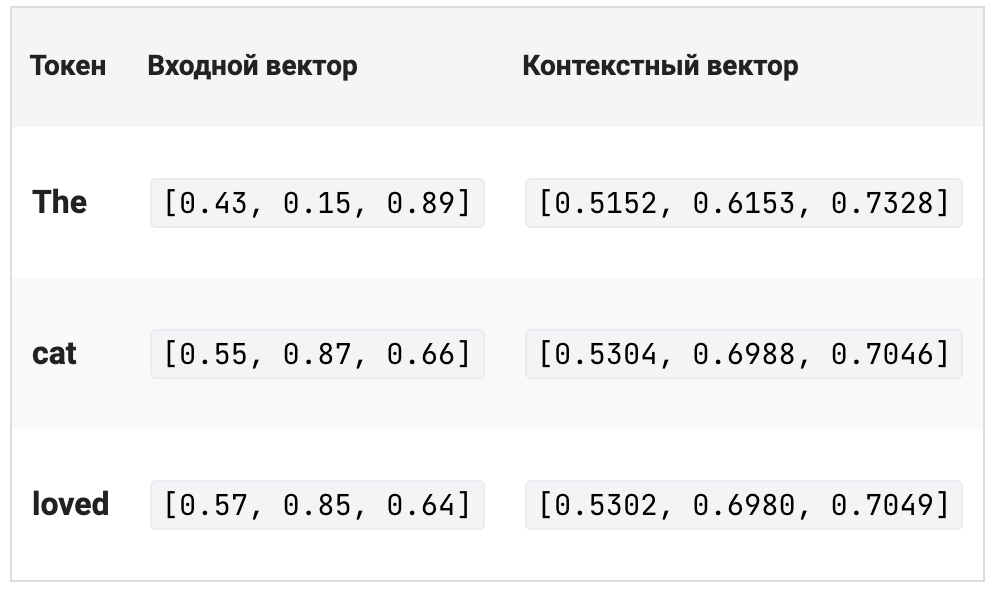

**Наблюдения:**

1. Размерность сохранилась: На входе было 3 вектора по 3 числа, на выходе - тоже 3 вектора по 3 числа.
2. Векторы изменились: Каждый контекстный вектор - это смесь всех входных векторов. Например, вектор «cat» теперь содержит информацию от «The» и «loved» тоже.
3. «cat» и «loved» стали похожее: Их контекстные векторы стали более похожими ([0.5304, 0.6988, 0.7046] vs [0.5302, 0.6980, 0.7049]). Это потому, что они уделяли друг другу много внимания.
4. «The» остался немного другим: Его контекстный вектор отличается больше, потому что исходный вектор «The» был уникальным (большое значение в 3-м измерении).

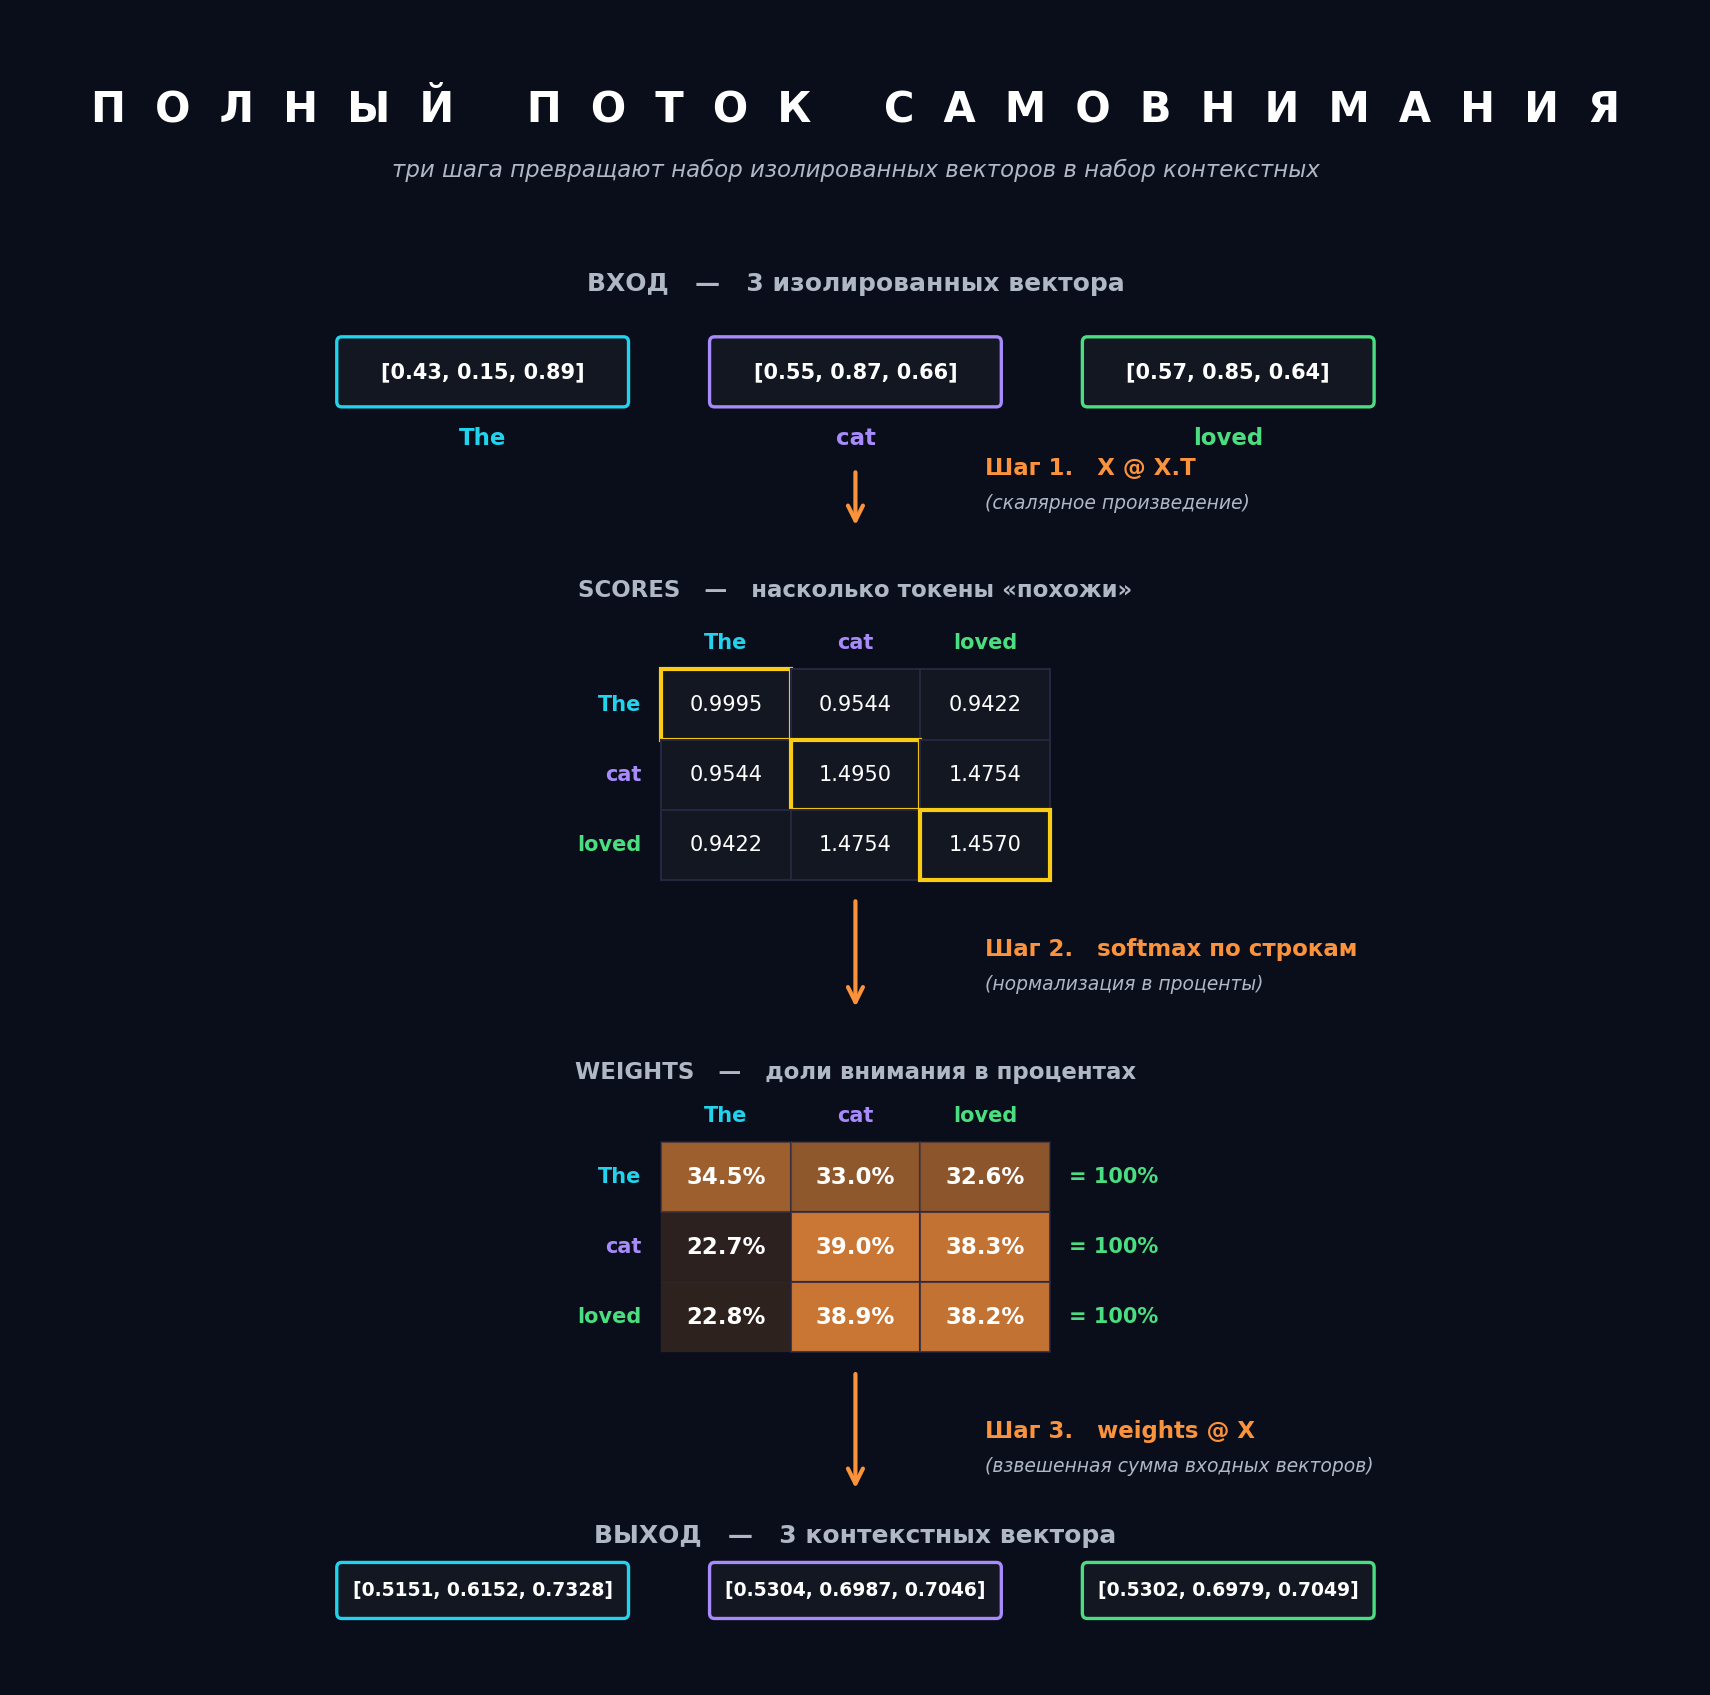

Создадим файл `attention_simple.py` -- в нём реализуем всю текущую составляющую механизма внимания

Теперь напишем маленький скрипт, который возьмёт те же самые векторы, что мы считали вручную (The, cat, loved), прогонит их через нашу функцию и через класс - и проверит, что код даёт те же числа. `demo_attention_manual.py`

Перенесём также данные файлы в директорию `simple_llm`